# 03 - Ripasso di Statistica: L'Equazione più Pericolosa

Nel suo famoso articolo del 2007, Howard Wainer scrive a proposito di equazioni molto pericolose:

"Alcune equazioni sono pericolose se le conosci, e altre sono pericolose se non le conosci. La prima categoria può rappresentare un pericolo perché i segreti entro i suoi confini aprono porte dietro le quali si cela un terribile periglio. L'ovvio vincitore in questo è l'iconica equazione di Einstein $E = mc^2$, poiché fornisce una misura dell'enorme energia nascosta all'interno della materia ordinaria. \[...\] Invece mi interessano le equazioni che scatenano il loro pericolo non quando le conosciamo, ma piuttosto quando non le conosciamo. Tenute a portata di mano, queste equazioni ci permettono di capire le cose chiaramente, ma la loro assenza ci lascia pericolosamente ignoranti."

L'equazione di cui parla è l'equazione di Moivre:

$
SE = \dfrac{\sigma}{\sqrt{n}} 
$

dove $SE$ è l'errore standard della media, $\sigma$ è la deviazione standard e $n$ è la dimensione del campione. Sembra un pezzo di matematica che i coraggiosi e i veri dovrebbero padroneggiare, quindi mettiamoci all'opera.


[n.d.t. standard deviation, calcolata come  $\sqrt{\dfrac{\sum_{i=1}^{n}(x_i - \bar{x})]^2}{n}}$, chiamata pure scarto quadratico medio ]




Per capire perché non conoscere questa equazione sia molto pericoloso, guardiamo alcuni dati sull'istruzione. Ho raccolto i dati sui punteggi ENEM (punteggi standardizzati delle scuole superiori brasiliane, simili ai SAT) di diverse scuole per 3 anni. Ho anche pulito i dati per mantenere solo le informazioni rilevanti per noi. I dati originali possono essere scaricati sul [sito web dell'Inep](http://portal.inep.gov.br/web/guest/microdados#).

Se guardiamo le scuole con i migliori risultati, qualcosa salta all'occhio: queste scuole hanno un numero di studenti ragionevolmente piccolo. 

Nel suo famoso articolo del 2007, Howard Wainer scrive di equazioni molto pericolose:

"Alcune equazioni sono pericolose se le conosci, altre lo sono se non le conosci. La prima categoria può essere pericolosa perché i segreti nascosti in essa aprono porte dietro cui si celano pericoli terribili. Il vincitore ovvio è l'iconica equazione di Einstein $E = mc^2$, perché fornisce una misura dell'enorme energia nascosta nella materia ordinaria. \[...\] Invece sono interessato a equazioni che scatenano il loro pericolo non quando sappiamo di loro, ma piuttosto quando non lo sappiamo. Tenute a portata di mano, queste equazioni ci permettono di comprendere le cose chiaramente, ma la loro assenza ci lascia pericolosamente ignoranti."

L'equazione di cui parla è l'**equazione di Moivre**:

$
SE = \dfrac{\sigma}{\sqrt{n}}
$

dove $SE$ è l'**errore standard della media**, $\sigma$ è la **deviazione standard**, e $n$ è la dimensione del campione. Sembra un pezzo di matematica che i coraggiosi e consapevoli dovrebbero padroneggiare, quindi iniziamo.

[n.d.t. standard deviation, calcolata come  $\sqrt{\dfrac{\sum_{i=1}^{n}(x_i - \bar{x})    ]^2}{n}}$, chiamata pure scarto quadratico medio ]


Per capire perché non conoscere questa equazione è molto pericoloso, esaminiamo alcuni dati sull'istruzione. Ho raccolto dati sui punteggi ENEM (punteggi standardizzati delle scuole superiori brasiliane) di diverse scuole per 3 anni. Ho pulito i dati per mantenere solo le informazioni rilevanti per noi. I dati originali possono essere scaricati dal [sito Inep](http://portal.inep.gov.br/web/guest/microdados#).

Se guardiamo la **scuola con le migliori prestazioni**, qualcosa colpisce l'occhio: quelle scuole hanno **un numero ragionevolmente piccolo di studenti**.

In [9]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
style.use("fivethirtyeight")

In [10]:
df = pd.read_csv("./data/enem_scores.csv")
df.sort_values(by="avg_score", ascending=False).head(10)

,year,school_id,number_of_students,avg_score
16670,2007,33062633,68,82.97
16796,2007,33065403,172,82.04
16668,2005,33062633,59,81.89
16794,2005,33065403,177,81.66
10043,2007,29342880,43,80.32
18121,2007,33152314,14,79.82
16781,2007,33065250,80,79.67
3026,2007,22025740,144,79.52
14636,2007,31311723,222,79.41
17318,2007,33087679,210,79.38


Guardando la questione da un'altra angolazione, possiamo isolare solo l'1% delle migliori scuole e studiarle. Come sono fatte? Forse possiamo imparare qualcosa dalle migliori e replicarlo altrove. E, puntualmente, se guardiamo l'1% delle migliori scuole, scopriamo che hanno, in media, meno studenti.

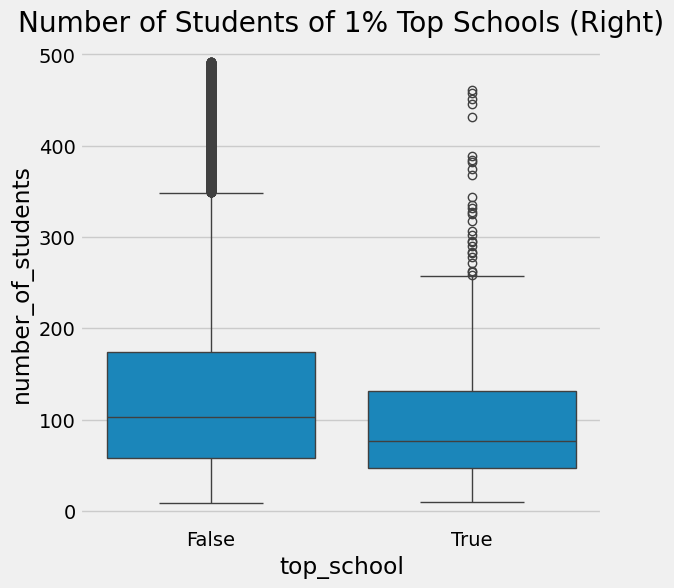

In [11]:
plot_data = (df
             .assign(top_school = df["avg_score"] >= np.quantile(df["avg_score"], .99))
             [["top_school", "number_of_students"]]
             .query(f"number_of_students<{np.quantile(df['number_of_students'], .98)}")) # remove outliers

plt.figure(figsize=(6,6))
sns.boxplot(x="top_school", y="number_of_students", data=plot_data)
plt.title("Number of Students of 1% Top Schools (Right)");

Una conclusione naturale è che le piccole scuole portino a prestazioni accademiche più elevate. Questo ha senso intuitivamente, poiché crediamo che meno studenti per insegnante permettano a quest'ultimo di dedicare un'attenzione mirata a ciascuno studente. Ma cosa c'entra questo con l'equazione di Moivre? E perché è pericoloso? 

Ebbene, diventa pericoloso quando le persone iniziano a prendere decisioni importanti e costose basate su queste informazioni. Nel suo articolo, Howard continua:

"Negli anni '90, divenne popolare sostenere la riduzione delle dimensioni delle scuole. Numerose organizzazioni filantropiche e agenzie governative hanno finanziato la divisione delle scuole più grandi perché gli studenti delle piccole scuole sono sovrarappresentati nei gruppi con punteggi elevati nei test."

Ciò che la gente ha dimenticato di fare è stato guardare anche all'1% delle scuole peggiori. Se lo facciamo, ecco che sorpresa! Anche loro hanno pochissimi studenti!

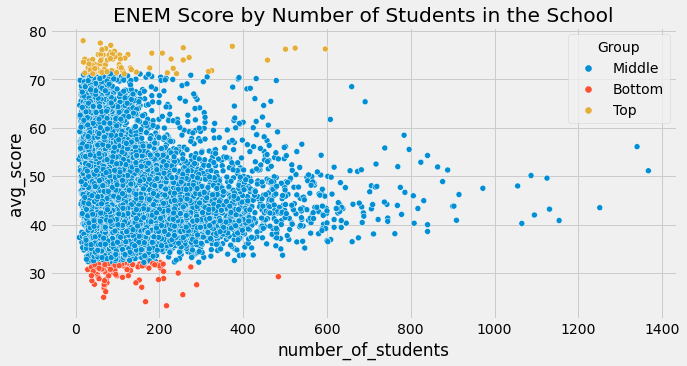

In [4]:
q_99 = np.quantile(df["avg_score"], .99)
q_01 = np.quantile(df["avg_score"], .01)

plot_data = (df
             .sample(10000)
             .assign(Group = lambda d: np.select([d["avg_score"] > q_99, d["avg_score"] < q_01],
                                                 ["Top", "Bottom"], "Middle")))
plt.figure(figsize=(10,5))
sns.scatterplot(y="avg_score", x="number_of_students", hue="Group", data=plot_data)
plt.title("ENEM Score by Number of Students in the School");

Stiamo vedendo sopra esattamente ciò che ci si aspetta secondo l'equazione di Moivre. Man mano che il numero di studenti cresce, il punteggio medio diventa sempre più preciso. Le scuole con pochissimi campioni possono avere punteggi molto alti o molto bassi semplicemente per puro caso. È meno probabile che ciò accada nelle grandi scuole. L'equazione di Moivre parla di un fatto fondamentale sulla realtà dell'informazione e delle registrazioni sotto forma di dati: è sempre imprecisa. La domanda diventa quindi *quanto* imprecisa.

La statistica è la scienza che si occupa di queste imprecisioni, in modo che non ci colgano alla sprovvista. Come dice Taleb nel suo libro, *Giocati dal Caso*:

> La probabilità non è un mero calcolo delle probabilità sui dadi o varianti più complicate; è l'accettazione della mancanza di certezza nella nostra conoscenza e lo sviluppo di metodi per affrontare la nostra ignoranza.

Un modo per quantificare la nostra incertezza è la **varianza delle nostre stime**. La varianza ci dice quanto un'osservazione devia dal suo valore centrale e più probabile. Come indica l'equazione di Moivre, questa incertezza diminuisce all'aumentare della quantità di dati che osserviamo. Questo ha senso, no? Se vediamo molti studenti che ottengono risultati eccellenti in una scuola, possiamo essere più fiduciosi che si tratti effettivamente di una buona scuola. Tuttavia, se vediamo una scuola con soli 10 studenti e 8 di loro ottengono buoni risultati, dobbiamo essere più sospettosi. Per puro caso, potrebbe essere che la scuola abbia avuto alcuni studenti sopra la media.

Il bellissimo grafico a triangolo che vediamo sopra racconta proprio questa storia. Ci mostra come le nostre stime della prestazione scolastica abbiano un'enorme varianza quando le dimensioni del campione sono piccole. Indica anche che la varianza diminuisce all'aumentare della dimensione del campione. Questo è vero per il punteggio medio in una scuola, ma è vero anche per qualsiasi statistica riassuntiva che abbiamo, incluso l'ATE che spesso vogliamo stimare.

## L'Errore Standard delle Nostre Stime

Poiché si tratta solo di un ripasso di statistica, mi prenderò la libertà di andare un po' più veloce ora. Se non hai familiarità con distribuzioni, varianza ed errori standard, continua a leggere, ma tieni presente che potresti aver bisogno di alcune risorse aggiuntive. Ti suggerisco di cercare su Google un qualsiasi corso del MIT di introduzione alla statistica. Di solito sono ottimi.

Nella sezione precedente, abbiamo stimato l'effetto medio del trattamento $E[Y_1-Y_0]$ come la differenza tra le medie del gruppo trattato e di quello non trattato $E[Y|T=1]-E[Y|T=0]$. Abbiamo calcolato l' $ATE$ per le lezioni online come nostro esempio motivante. Abbiamo anche visto un impatto negativo; le lezioni online hanno fatto sì che gli studenti ottenessero prestazioni inferiori di circa 5 punti rispetto agli studenti con lezioni frontali. **Ora vedremo se questo impatto è statisticamente significativo**.

Per fare ciò, dobbiamo stimare l' $SE$. Abbiamo già $n$, la dimensione del nostro campione. Per ottenere la stima della deviazione standard, possiamo fare quanto segue

$$
\hat{\sigma}=\sqrt{\frac{1}{N-1}\sum_{i=1}^N (x_i-\bar{x})^2}
$$

dove $\bar{x}$ è la media di $x$. Fortunatamente per noi, la maggior parte dei software di programmazione lo implementa già. In Pandas, possiamo usare il metodo [std](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.std.html).

In [12]:
data = pd.read_csv("./data/online_classroom.csv")
online = data.query("format_ol==1")["falsexam"]
face_to_face = data.query("format_ol==0 & format_blended==0")["falsexam"]

def se(y: pd.Series):
    return y.std() / np.sqrt(len(y))

print("SE for Online:", se(online))
print("SE for Face to Face:", se(face_to_face))

SE for Online: 1.5371593973041635
SE for Face to Face: 0.8723511456319106


## Intervalli di Confidenza

L'errore standard della nostra stima è una misura della fiducia. Dobbiamo addentrarci in acque statistiche turbolente e polemiche per capire esattamente cosa significhi. Per una visione della statistica, quella **frequentista**, diremmo che i nostri dati non sono altro che una manifestazione di un accurato processo di generazione dei dati. Questo processo è astratto e ideale. È governato da **parametri reali che sono immutabili ma anche a noi ignoti**. Nel contesto del test degli studenti, se potessimo eseguire più esperimenti e raccogliere più set di dati, tutti assomiglierebbero al vero processo di generazione dei dati sottostante, ma non sarebbero esattamente identici ad esso. Questo è molto simile a quanto scritto da Platone sulle Forme:

> Ciascuna [delle forme essenziali] si manifesta in una grande varietà di combinazioni, con azioni, con cose materiali e l'una con l'altra, e ciascuna sembra essere molte

Supponiamo di avere una vera distribuzione astratta dei punteggi dei test degli studenti per comprenderlo meglio. Si tratta di una distribuzione normale con una media reale di 74 e una deviazione standard reale di 2. Da questa distribuzione, possiamo eseguire 10.000 esperimenti. In ognuno di essi, raccogliamo 500 campioni. Se li tracciamo in un istogramma, possiamo vedere che le medie degli esperimenti sono distribuite intorno alla media reale. Alcuni dati sperimentali avranno una media inferiore a quella reale, altri superiore.

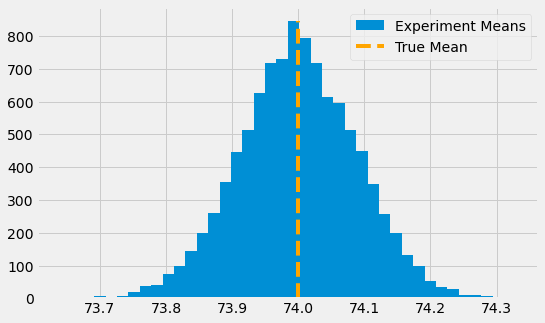

In [6]:
true_std = 2
true_mean = 74

n = 500
def run_experiment(): 
    return np.random.normal(true_mean,true_std, 500)

np.random.seed(42)

plt.figure(figsize=(8,5))
freq, bins, img = plt.hist([run_experiment().mean() for _ in range(10000)], bins=40, label="Experiment Means")
plt.vlines(true_mean, ymin=0, ymax=freq.max(), linestyles="dashed", label="True Mean", color="orange")
plt.legend();


Nota che qui stiamo parlando della media delle medie. Quindi, per caso, potremmo avere un esperimento in cui la media sia un po' al di sotto o al di sopra della media reale. Vale a dire che non potremo mai essere sicuri che la media del nostro esperimento corrisponda alla vera media platonica e ideale. Tuttavia, **con l'errore standard, possiamo creare un intervallo che conterrà la media reale il 95% delle volte**.

Nella vita reale, non abbiamo il lusso di simulare lo stesso esperimento con più set di dati. Spesso ne abbiamo solo uno. Ma possiamo attingere all'intuizione di cui sopra per costruire quelli che chiamiamo **intervalli di confidenza**. Gli intervalli di confidenza hanno una probabilità associata ad essi. La più comune è il 95%. Questa probabilità ci dice quanti ipotetici intervalli di confidenza che costruiremmo a partire da diversi studi conterranno la media reale. Ad esempio, gli intervalli di confidenza al 95% calcolati da studi simili includerebbero la media reale nel 95% dei casi.

Per calcolare l'intervallo di confidenza, utilizziamo il **teorema del limite centrale**. Questo teorema afferma che **le medie degli esperimenti sono distribuite normalmente**. Dalla teoria statistica, sappiamo che il 95% della massa di una distribuzione normale si trova tra 2 deviazioni standard sopra e sotto la media. Tecnicamente 1,96, ma 2 è abbastanza vicino.

![normal_density](./data/img/stats-review/normal_dist.jpeg)

L'Errore Standard della media funge da nostra stima della distribuzione delle medie degli esperimenti. Quindi, se lo moltiplichiamo per 2 e lo sommiamo e lo sottraiamo dalla media di uno dei nostri esperimenti, costruiremo un intervallo di confidenza al 95% per la media reale.

In [7]:
np.random.seed(321)
exp_data = run_experiment()
exp_se = exp_data.std() / np.sqrt(len(exp_data))
exp_mu = exp_data.mean()
ci = (exp_mu - 2 * exp_se, exp_mu + 2 * exp_se)
print(ci)

(73.82718114045632, 74.17341543460314)


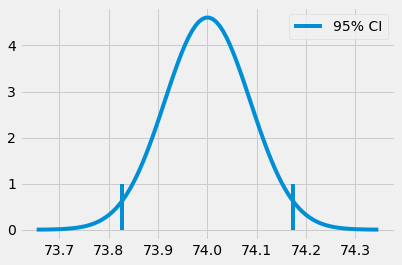

In [8]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)
plt.plot(x, y)
plt.vlines(ci[1], ymin=0, ymax=1)
plt.vlines(ci[0], ymin=0, ymax=1, label="95% CI")
plt.legend()
plt.show()

Naturalmente, non dobbiamo limitarci all'intervallo di confidenza del 95%. Potremmo generare l'intervallo del 99% trovando il valore per cui moltiplicare la deviazione standard in modo che l'intervallo contenga il 99% della massa di una distribuzione normale.

La funzione `ppf` in Python ci fornisce l'inversa della funzione di distribuzione cumulativa (CDF). Invece di moltiplicare l'errore standard per 2 come abbiamo fatto per trovare l'intervallo di confidenza del 95%, lo moltiplicheremo per `z`, ottenendo così l'intervallo di confidenza del 99%. Quindi, `ppf(0.5)` restituirà 0.0, indicando che il 50% della massa della distribuzione normale standard (media 0 e deviazione standard 1) è inferiore a 0.0. Allo stesso modo, se sostituiamo 99.5%, otterremo il valore `z`, tale che il 99.5% della massa della distribuzione si trova al di sotto di questo valore. In altre parole, lo 0.5% della massa si trova al di sopra di questo valore.

In [9]:
from scipy import stats
z = stats.norm.ppf(.995)
print(z)
ci = (exp_mu - z * exp_se, exp_mu + z * exp_se)
ci

2.5758293035489004


(73.7773381773405, 74.22325839771896)

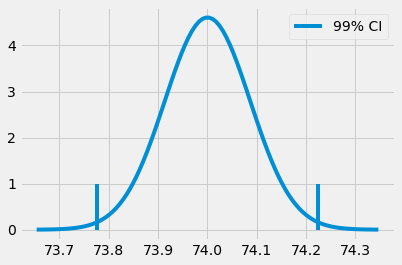

In [10]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)
plt.plot(x, y)
plt.vlines(ci[1], ymin=0, ymax=1)
plt.vlines(ci[0], ymin=0, ymax=1, label="99% CI")
plt.legend()
plt.show()

Tornando al nostro esperimento in classe, possiamo costruire l'intervallo di confidenza per il punteggio medio dell'esame sia per il gruppo di studenti online che per quello in presenza.

In [11]:
def ci(y: pd.Series):
    return (y.mean() - 2 * se(y), y.mean() + 2 * se(y))

print("95% CI for Online:", ci(online))
print("95% for Face to Face:", ci(face_to_face))

95% CI for Online: (70.56094429049804, 76.7095818797147)
95% for Face to Face: (76.80278229206951, 80.29218687459715)


Possiamo vedere che gli **intervalli di confidenza al 95% dei gruppi non si sovrappongono**. L'estremo inferiore dell'IC per la classe frontale è al di sopra dell'estremo superiore dell'IC per le lezioni online. **Questa è la prova che il nostro risultato non è dovuto al caso** e che la media reale per gli studenti nelle lezioni frontali è superiore alla media reale per gli studenti nelle lezioni online. In altre parole, c'è un calo causale significativo nelle prestazioni accademiche quando si passa dalle lezioni frontali a quelle online.

Ricapitolando, gli intervalli di confidenza sono un modo per porre l'incertezza intorno alle nostre stime. **Minore è la dimensione del campione, maggiore è l'errore standard e più ampio è l'intervallo di confidenza**. Poiché sono facilissimi da calcolare, **la mancanza di intervalli di confidenza segnala cattive intenzioni o semplicemente mancanza di conoscenza**, il che è altrettanto preoccupante. Infine, dovresti sempre diffidare delle misurazioni prive di una metrica di incertezza.

![img](data/img/stats-review/ci_xkcd.png)

Un'ultima avvertenza. Gli intervalli di confidenza sono più difficili da interpretare di quanto sembri a prima vista. Ad esempio, **non** dovrei dire che "questo particolare intervallo di confidenza al 95%" contenga la media reale della popolazione con una probabilità del 95%. Nella statistica frequentista che utilizza intervalli di confidenza, la media della popolazione è considerata una costante reale della popolazione. Quindi o si trova o non si trova nel nostro particolare intervallo di confidenza. In altre parole, il nostro specifico intervallo di confidenza contiene o meno la media reale. Se la contiene, la probabilità di contenerla sarebbe del 100%, non del 95%. In caso contrario, la probabilità sarebbe dello 0%. Invece, **negli intervalli di confidenza, il 95% si riferisce alla frequenza con cui tali intervalli di confidenza, calcolati in molti studi, contengono la media reale**. Il 95% è la nostra fiducia nell'algoritmo utilizzato per calcolare l'IC al 95%, non nel particolare intervallo in sé.

Detto questo, come economista (gli statistici non guardino ora), penso che questo purismo non sia molto utile. In pratica, vedrai persone affermare che il particolare intervallo di confidenza contenga la media reale nel 95% dei casi. Sebbene errato, questo non è molto dannoso, in quanto pone comunque un preciso grado di incertezza nelle nostre stime. Inoltre, se passassimo alla statistica bayesiana e usassimo intervalli credibili (probable intervals) invece di intervalli di confidenza, saremmo in grado di dire che l'intervallo contenga la media della distribuzione nel 95% dei casi. Inoltre, da quanto ho visto nella pratica, con dimensioni campionarie decenti, gli intervalli di probabilità bayesiani sono più simili agli intervalli di confidenza di quanto i bayesiani e i frequentisti vorrebbero ammettere. Quindi, se la mia parola conta qualcosa, sentiti libero di dire quello che vuoi sul tuo intervallo di confidenza. Non mi importa se dici che contengono la media reale nel 95% dei casi. Per favore, **non dimenticare mai di porli intorno alle tue stime; altrimenti sembrerai sciocco**.


## Verifica delle Ipotesi

Un altro modo per incorporare l'incertezza è formulare un test di ipotesi: la differenza tra le medie è statisticamente diversa da zero (o da qualsiasi altro valore)? Ricorderemo che la somma o la differenza di 2 distribuzioni normali indipendenti è anch'essa una distribuzione normale. La media risultante sarà la somma o la differenza tra le due distribuzioni, mentre la varianza sarà sempre la somma delle varianze:

$
N(\mu_1, \sigma_1^2) - N(\mu_2, \sigma_2^2) = N(\mu_1 - \mu_2, \sigma_1^2 + \sigma_2^2)
$

$
N(\mu_1, \sigma_1^2) + N(\mu_2, \sigma_2^2) = N(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)
$

Se non ricordi, va bene lo stesso. Possiamo sempre usare il codice e i dati simulati per controllare:

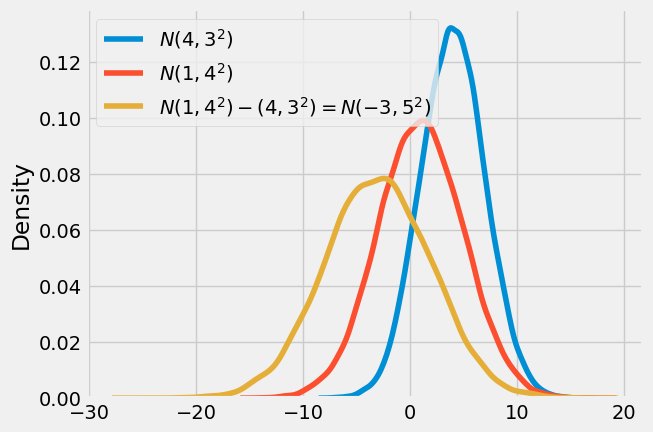

In [14]:
np.random.seed(123)
n1 = np.random.normal(4, 3, 30000)
n2 = np.random.normal(1, 4, 30000)
n_diff = n2 - n1
sns.distplot(n1, hist=False, label="$N(4,3^2)$")
sns.distplot(n2, hist=False, label="$N(1,4^2)$")
sns.distplot(n_diff, hist=False, label=f"$N(1,4^2) - (4,3^2) = N(-3, 5^2)$")
plt.legend()
plt.show()

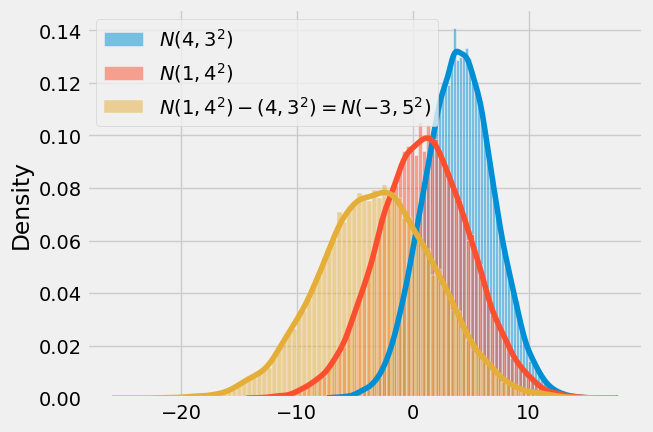

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(123)
n1 = np.random.normal(4, 3, 30000)
n2 = np.random.normal(1, 4, 30000)
n_diff = n2 - n1

sns.histplot(n1, kde=True, stat="density", label="$N(4,3^2)$")
sns.histplot(n2, kde=True, stat="density", label="$N(1,4^2)$")
sns.histplot(n_diff, kde=True, stat="density", label=f"$N(1,4^2) - (4,3^2) = N(-3, 5^2)$")

plt.legend()
plt.show()

Se prendiamo la distribuzione delle medie dei nostri 2 gruppi e ne sottraiamo una dall'altra, avremo una terza distribuzione. La media di questa distribuzione finale sarà la differenza tra le medie, e la deviazione standard di questa distribuzione sarà la radice quadrata della somma delle deviazioni standard.

$
\mu_{diff} = \mu_1 - \mu_2
$

$
SE_{diff} = \sqrt{SE^2_1 + SE^2_2} = \sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}
$

Torniamo al nostro esempio della classe. Costruiremo questa distribuzione della differenza. Ovviamente, una volta ottenuta, costruire l'IC al 95% è semplice.

In [16]:
diff_mu = online.mean() - face_to_face.mean()
diff_se = np.sqrt(face_to_face.var()/len(face_to_face) + online.var()/len(online))
ci = (diff_mu - 1.96*diff_se, diff_mu + 1.96*diff_se)
print(ci)

(np.float64(-8.376410208363385), np.float64(-1.4480327880905248))


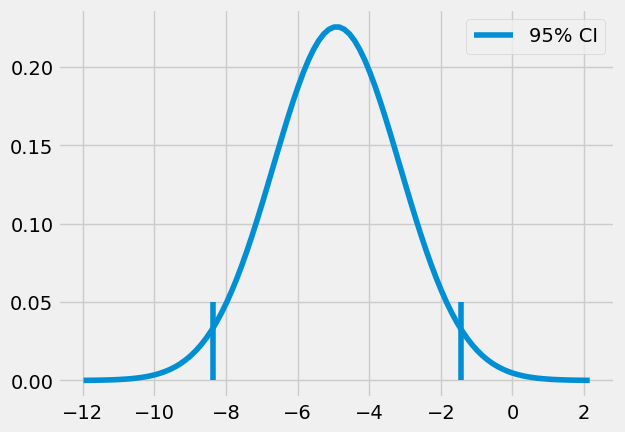

In [ ]:
x = np.linspace(diff_mu - 4*diff_se, diff_mu + 4*diff_se, 100)
y = stats.norm.pdf(x, diff_mu, diff_se)
plt.plot(x, y)
plt.vlines(ci[1], ymin=0, ymax=.05)
plt.vlines(ci[0], ymin=0, ymax=.05, label="95% CI")
plt.legend()
plt.show()

Con questi dati a disposizione, possiamo affermare con una sicurezza del 95% che la vera differenza tra il gruppo online e quello in presenza sia compresa tra -8,37 e -1,44. Possiamo inoltre calcolare una **statistica z** dividendo la differenza tra le medie per l'errore standard (SE) delle differenze.

$
z = \dfrac{\mu_{diff} - H_{0}}{SE_{diff}} = \dfrac{(\mu_1 - \mu_2) - H_{0}}{\sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}}
$

Dove $H_0$ è il valore di riferimento rispetto al quale vogliamo confrontare la nostra differenza.

La statistica z misura quanto sia estrema la differenza osservata. Useremo la contraddizione per verificare la nostra ipotesi che la differenza tra le medie sia statisticamente diversa da zero. Ipotizzeremo che sia vero il contrario, ovvero che la differenza sia zero. Questa viene chiamata ipotesi nulla, o $H_0$. Ci chiederemo quindi: "È probabile che osserviamo una tale differenza se la vera differenza fosse zero?". Possiamo tradurre questa domanda, in termini statistici, nel verificare quanto la nostra statistica z si discosti da zero.

Sotto l'ipotesi nulla $H_0$, la statistica z segue una distribuzione normale standard. Pertanto, se la differenza è effettivamente zero, osserveremmo la statistica z entro 2 deviazioni standard dalla media nel 95% dei casi. La conseguenza diretta è che se z si trova al di sopra o al di sotto di 2 deviazioni standard, possiamo rifiutare l'ipotesi nulla con una confidenza del 95%.

Vediamo come questo si traduce nel nostro esempio in classe.

With this at hand, we can say that we are 95% confident that the true difference between the online and face-to-face groups falls between -8.37 and -1.44. We can also construct a **z statistic** by dividing the difference in mean by the $SE$ of the differences.

$
z = \dfrac{\mu_{diff} - H_{0}}{SE_{diff}} = \dfrac{(\mu_1 - \mu_2) - H_{0}}{\sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}}
$

Where $H_0$ is the value which we want to test our difference against.

The z statistic is a measure of how extreme the observed difference is. We will use contradiction to test our hypothesis that the difference in the means is statistically different from zero. We will assume that the opposite is true; we will assume that the difference is zero. This is called a null hypothesis, or $H_0$. Then, we will ask ourselves, "is it likely that we would observe such a difference if the true difference were zero?" We can translate this question to checking how far from zero is our z statistic in statistical math terms. 

Under $H_0$, the z statistic follows a standard normal distribution. So, if the difference is indeed zero, we would see the z statistic within 2 standard deviations of the mean 95% of the time. The direct consequence is that if z falls above or below 2 standard deviations, we can reject the null hypothesis with 95% confidence.

Let's see how this looks like in our classroom example.

In [15]:
z = diff_mu / diff_se
print(z)

-2.7792810791031224


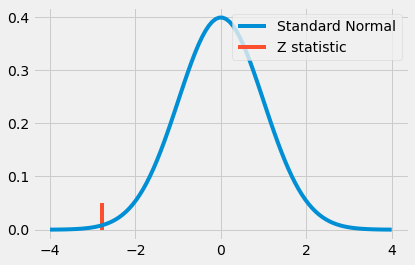

In [16]:
x = np.linspace(-4,4,100)
y = stats.norm.pdf(x, 0, 1)
plt.plot(x, y, label="Standard Normal")
plt.vlines(z, ymin=0, ymax=.05, label="Z statistic", color="C1")
plt.legend()
plt.show()

Questo sembra un valore piuttosto estremo. In effetti è superiore a 2, il che significa che c'è meno del 5% di probabilità di osservare un valore così estremo se non ci fosse alcuna differenza tra i gruppi. Questo ci porta di nuovo a concludere che il passaggio dalle lezioni frontali a quelle online provochi un calo statisticamente significativo dei risultati accademici.

Un'ultima cosa interessante sui test di ipotesi è che sono meno conservativi rispetto al controllo della sovrapposizione dell'IC al 95% tra il gruppo trattato e quello non trattato. In altre parole, se gli intervalli di confidenza dei due gruppi si sovrappongono, può comunque accadere che il risultato sia statisticamente significativo. Per esempio, facciamo finta che il gruppo con lezioni frontali abbia un punteggio medio di 80 con un errore standard di 4, e il gruppo online abbia un punteggio medio di 71 con un errore standard di 2.

In [17]:
cont_mu, cont_se =  (71, 2)
test_mu, test_se = (80, 4)

diff_mu = test_mu - cont_mu
diff_se = np.sqrt(cont_se**2 + test_se**2)

print("Control 95% CI:", (cont_mu-1.96*cont_se, cont_mu+1.96*cont_se))
print("Test 95% CI:", (test_mu-1.96*test_se, test_mu+1.96*test_se))
print("Diff 95% CI:", (diff_mu-1.96*diff_se, diff_mu+1.96*diff_se))

Control 95% CI: (67.08, 74.92)
Test 95% CI: (72.16, 87.84)
Diff 95% CI: (0.23461352820082482, 17.765386471799175)


Se costruiamo gli intervalli di confidenza per questi gruppi, si sovrappongono. Il limite superiore dell'IC al 95% per il gruppo online è 74,92 e il limite inferiore per il gruppo frontale è 72,16. Tuttavia, una volta calcolato l'intervallo di confidenza al 95% per la differenza tra i gruppi, possiamo vedere che non contiene lo zero. Anche se i singoli intervalli di confidenza si sovrappongono, la differenza può comunque essere statisticamente diversa da zero.

## P-value

In precedenza, ho detto che c'è meno del 5% di probabilità di osservare un valore così estremo se la differenza tra i gruppi online e frontale fosse effettivamente zero. Ma possiamo stimare con precisione questa probabilità? Quanto è probabile osservare un valore così estremo? Entrano in gioco i p-value!

Come per gli intervalli di confidenza (e per la maggior parte delle statistiche frequentiste, del resto), la vera definizione di p-value può creare molta confusione. Quindi, per non correre rischi, copierò la definizione da Wikipedia: "il p-value è la probabilità di ottenere risultati del test almeno altrettanto estremi dei risultati effettivamente osservati durante il test, supponendo che l'ipotesi nulla sia corretta".

Per dirla più sinteticamente, il p-value è la probabilità di vedere tali dati, dato che l'ipotesi nulla è vera. Misura quanto sia improbabile osservare una misurazione se l'ipotesi nulla è vera. Naturalmente, questo viene spesso confuso con la probabilità che l'ipotesi nulla sia vera. Nota la differenza qui. Il p-value NON è $P(H_0|data)$, bensì $P(data|H_0)$.

Ma non lasciarti ingannare da questa complessità. In termini pratici, sono piuttosto semplici da usare.

![p_value](./data/img/stats-review/p_value.png)

Per ottenere il p-value, dobbiamo calcolare l'area sotto la distribuzione normale standard prima o dopo la statistica z. Fortunatamente, abbiamo un computer che esegue questo calcolo per noi. Possiamo semplicemente inserire la statistica z nella CDF della distribuzione normale standard.

In [18]:
print("P-value:", stats.norm.cdf(z))

P-value: 0.0027239680835563383


Nota come il p-value sia interessante perché evita di dover specificare un livello di confidenza, come il 95% o il 99%. Ma, se desideriamo riportarne uno, dal p-value sappiamo esattamente a quale confidenza il nostro test supererà o meno la prova. Per esempio, con un p-value di 0,0027, vediamo che abbiamo una significatività fino al livello dello 0,2%. Quindi, mentre né l'IC al 95% né l'IC al 99% per la differenza conterranno lo zero, l'IC al 99,9% lo conterrà. Ciò significa che c'è solo lo 0,2% di probabilità di osservare questa statistica z estrema se la differenza fosse pari a zero.

In [19]:
diff_mu = online.mean() - face_to_face.mean()
diff_se = np.sqrt(face_to_face.var()/len(face_to_face) + online.var()/len(online))
print("95% CI:", (diff_mu - stats.norm.ppf(.975)*diff_se, diff_mu + stats.norm.ppf(.975)*diff_se))
print("99% CI:", (diff_mu - stats.norm.ppf(.995)*diff_se, diff_mu + stats.norm.ppf(.995)*diff_se))
print("99.9% CI:", (diff_mu - stats.norm.ppf(.9995)*diff_se, diff_mu + stats.norm.ppf(.9995)*diff_se))

95% CI: (-8.376346553082909, -1.4480964433710017)
99% CI: (-9.46485353526404, -0.3595894611898709)
99.9% CI: (-10.728040658245558, 0.9035976617916459)


## Idee Chiave

Abbiamo visto quanto sia importante conoscere l'equazione di Moivre e l'abbiamo usata per porre un grado di certezza intorno alle nostre stime. In particolare, abbiamo scoperto che le lezioni online causano un calo dei risultati accademici rispetto alle lezioni frontali. Abbiamo anche visto che si tratta di un risultato statisticamente significativo. Lo abbiamo fatto confrontando gli Intervalli di Confidenza delle medie per i 2 gruppi, osservando l'intervallo di confidenza per la differenza, effettuando una verifica delle ipotesi e osservando il p-value. Riassumiamo tutto in un'unica funzione che effettua il confronto del test A/B come quello che abbiamo fatto sopra

In [20]:
def AB_test(test: pd.Series, control: pd.Series, confidence=0.95, h0=0):
    mu1, mu2 = test.mean(), control.mean()
    se1, se2 = test.std() / np.sqrt(len(test)), control.std() / np.sqrt(len(control))
    
    diff = mu1 - mu2
    se_diff = np.sqrt(test.var()/len(test) + control.var()/len(control))
    
    z_stats = (diff-h0)/se_diff
    p_value = stats.norm.cdf(z_stats)
    
    def critical(se): return -se*stats.norm.ppf((1 - confidence)/2)
    
    print(f"Test {confidence*100}% CI: {mu1} +- {critical(se1)}")
    print(f"Control {confidence*100}% CI: {mu2} +- {critical(se2)}")
    print(f"Test-Control {confidence*100}% CI: {diff} +- {critical(se_diff)}")
    print(f"Z Statistic {z_stats}")
    print(f"P-Value {p_value}")
        
AB_test(online, face_to_face)

Test 95.0% CI: 73.63526308510637 +- 3.0127770572134565
Control 95.0% CI: 78.54748458333333 +- 1.7097768273108005
Test-Control 95.0% CI: -4.912221498226955 +- 3.4641250548559537
Z Statistic -2.7792810791031224
P-Value 0.0027239680835563383


Poiché la nostra funzione è abbastanza generica, possiamo testare altre ipotesi nulle. Per esempio, possiamo provare a rifiutare che la differenza tra le prestazioni delle lezioni online e frontali sia -1? Con i risultati ottenuti, possiamo dire con una confidenza del 95% che la differenza è più significativa di -1. Ma non possiamo dirlo con una confidenza del 99%:

In [21]:
AB_test(online, face_to_face, h0=-1)

Test 95.0% CI: 73.63526308510637 +- 3.0127770572134565
Control 95.0% CI: 78.54748458333333 +- 1.7097768273108005
Test-Control 95.0% CI: -4.912221498226955 +- 3.4641250548559537
Z Statistic -2.2134920404560883
P-Value 0.013431870694630114
